In [1]:
import os
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets

In [2]:
try:
    from torchinfo import summary
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchinfo"])
    from torchinfo import summary

try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchmetrics"])
    import torchmetrics


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import torchvision.transforms as T


transform = T.Compose([
    T.Resize((256, 256)),
    T.Lambda(lambda img: img.convert("RGB")),
    T.ToTensor(),
])



In [5]:
dataset = datasets.ImageFolder(root="/kaggle/input/caltech256/256_ObjectCategories", transform=transform)
# dataset = datasets.Caltech256(root='./data', download=True, transform=transform)
# dataset = datasets.Caltech101(root='./data', download=True, transform=transform)
# Using x% of the dataset
subset_size = int(0.1 * len(dataset))  
train_size = int(0.8 * subset_size)  
test_size = subset_size - train_size  

subset_dataset, _ = torch.utils.data.random_split(dataset, [subset_size, len(dataset) - subset_size])

train_dataset, test_dataset = torch.utils.data.random_split(subset_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count(), drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)

In [6]:
print(f"Train Dataset Length: {len(train_dataset)}")
print(f"Test Dataset Length: {len(test_dataset)}")
print(f"Train DataLoader Length: {len(train_loader)}")
print(f"Test DataLoader Length: {len(test_loader)}")

sample, label = next(iter(train_loader))
print(f"Sample Shape: {sample.shape}")
print(f"Label Shape: {label.shape}")

Train Dataset Length: 2448
Test Dataset Length: 612
Train DataLoader Length: 76
Test DataLoader Length: 19
Sample Shape: torch.Size([32, 3, 256, 256])
Label Shape: torch.Size([32])


In [7]:
import io
import torch
import torchvision
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torchvision.transforms import functional as TF
from PIL import Image
from torch.amp import autocast, GradScaler
from torchmetrics import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from tqdm import tqdm



# Perceptual Loss

class PerceptualLoss(nn.Module):
    def __init__(self, layer_ids=[8, 15], weights=[1.0, 1.0]):
        """
        Uses a pretrained VGG16 to compute a perceptual loss.
        layer_ids: indices of layers in VGG16.features whose output will be used.
                   For example, layer 8 corresponds roughly to conv2_2, and layer 15 to conv3_3.
        weights: list of weights for each layer's loss.
        """
        super(PerceptualLoss, self).__init__()
        vgg = models.vgg16(pretrained=True).features
        self.vgg_layers = vgg.eval()
        for param in self.vgg_layers.parameters():
            param.requires_grad = False
        self.layer_ids = layer_ids
        self.weights = weights

    def forward(self, input_img, target_img):
        loss = 0.0
        x = input_img
        y = target_img
        for i, layer in enumerate(self.vgg_layers):
            x = layer(x)
            y = layer(y)
            if i in self.layer_ids:
                loss += self.weights[self.layer_ids.index(i)] * F.mse_loss(x, y)
        return loss



### Metrics:

def normalized_correlation(x, y):
    x_mean = torch.mean(x)
    y_mean = torch.mean(y)
    numerator = torch.sum((x - x_mean) * (y - y_mean))
    denominator = torch.sqrt(torch.sum((x - x_mean) ** 2) * torch.sum((y - y_mean) ** 2))
    return numerator / denominator



### Transforms

transform = T.Compose([
    T.Resize((256, 256)),
    T.Lambda(lambda img: img.convert("RGB")),
    T.ToTensor(),
])



### Attacks

def attack_gaussian(image, sigma=1.0):
    """Applies Gaussian blur with a given sigma value."""
    return TF.gaussian_blur(image, kernel_size=5, sigma=sigma)

def attack_salt_and_pepper(image, amount=0.05, s_vs_p=0.5):
    """Applies salt-and-pepper noise by modifying the tensor directly."""
    image_np = image.detach().cpu().numpy().copy()  # Detach to prevent autograd issues
    noise = np.random.rand(*image_np.shape)
    image_np[noise < amount * s_vs_p] = 0.0
    image_np[noise > 1 - amount * (1 - s_vs_p)] = 1.0
    return torch.from_numpy(image_np).to(image.device)

def attack_jpeg(image, quality=70):
    """Applies JPEG compression by converting to PIL, saving, and reloading."""
    if image.dim() == 4:  # Handle batch processing
        return torch.stack([attack_jpeg(img, quality) for img in image])

    buffer = io.BytesIO()
    image_pil = TF.to_pil_image(image.detach().cpu().squeeze(0))
    image_pil.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)

    image_reloaded = Image.open(buffer)
    return TF.to_tensor(image_reloaded).to(image.device)

def random_attack(image):
    """Randomly selects an attack including three Gaussian variations or no attack."""
    attacks = ['gaussian_1', 'gaussian_0.1', 'gaussian_0.05', 'salt_and_pepper', 'none']
    chosen = random.choice(attacks)

    if chosen == 'gaussian_1':
        return attack_gaussian(image, sigma=1.0)
    elif chosen == 'gaussian_0.1':
        return attack_gaussian(image, sigma=0.1)
    elif chosen == 'gaussian_0.05':
        return attack_gaussian(image, sigma=0.05)
    elif chosen == 'salt_and_pepper':
        return attack_salt_and_pepper(image)
    
    return image  # No attack

def apply_attacks(image, attacks):
    """Applies a list of attacks sequentially."""
    if attacks is None:
        return image
    if isinstance(attacks, str):
        attacks = [attacks]
    
    for attack in attacks:
        if attack == 'gaussian_1':
            image = attack_gaussian(image, sigma=1.0)
        elif attack == 'gaussian_0.1':
            image = attack_gaussian(image, sigma=0.1)
        elif attack == 'gaussian_0.05':
            image = attack_gaussian(image, sigma=0.05)
        elif attack == 'salt_and_pepper':
            image = attack_salt_and_pepper(image)
        elif attack == 'jpeg':
            image = attack_jpeg(image)
    
    return image



### Visualize

import matplotlib.pyplot as plt

def visualize_images(cover, secret, stego, secret_revealed):
    """
    Shows cover, secret, stego and revealed images.
    """
    
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 4, 1)
    plt.title("Cover")
    plt.imshow(cover.permute(1, 2, 0))
    plt.axis('off')
    plt.subplot(1, 4, 2)
    plt.title("Secret")
    plt.imshow(secret.permute(1, 2, 0))
    plt.axis('off')
    plt.subplot(1, 4, 3)
    plt.title("Stego")
    plt.imshow(stego.permute(1, 2, 0))
    plt.axis('off')
    plt.subplot(1, 4, 4)
    plt.title("Revealed")
    plt.imshow(secret_revealed.permute(1, 2, 0))
    plt.axis('off')
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()    

def plot_psnr(metrics):
    epochs = range(1, len(metrics['loss']) + 1)
    plt.plot(epochs, metrics['psnr'], label='PSNR', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('PSNR (dB)')
    plt.title('Peak Signal-to-Noise Ratio (PSNR)')
    plt.legend()

def plot_cover_loss(metrics):
    epochs = range(1, len(metrics['loss']) + 1)
    plt.plot(epochs, metrics['pixel_loss_cover_stego'], label='Pixel Loss (Cover-Stego)', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Pixel Loss')
    plt.title('Pixel Loss (Cover-Stego)')
    plt.legend()

def plot_metrics(metrics):
    """
    Plots training metrics over epochs and prints final evaluation results.
    """
    
    epochs = range(1, len(metrics['loss']) + 1)
    
    # Plot Loss Curve
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 3, 1)
    plt.plot(epochs, metrics['loss'], label='Loss', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()

    # Plot PSNR Curve
    plt.subplot(2, 3, 2)
    plt.plot(epochs, metrics['psnr'], label='PSNR', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('PSNR (dB)')
    plt.title('Peak Signal-to-Noise Ratio (PSNR)')
    plt.legend()

    # Plot SSIM Curve
    plt.subplot(2, 3, 3)
    plt.plot(epochs, metrics['ssim'], label='SSIM', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('SSIM')
    plt.title('Structural Similarity Index (SSIM)')
    plt.legend()

    # Plot Normalized Correlation (NC) Curve
    plt.subplot(2, 3, 4)
    plt.plot(epochs, metrics['nc'], label='Normalized Correlation', color='purple')
    plt.xlabel('Epochs')
    plt.ylabel('NC')
    plt.title('Normalized Correlation (NC)')
    plt.legend()

    # Plot Pixel Loss (Cover-Stego)
    plt.subplot(2, 3, 5)
    plt.plot(epochs, metrics['pixel_loss_cover_stego'], label='Pixel Loss (Cover-Stego)', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Pixel Loss')
    plt.title('Pixel Loss (Cover-Stego)')
    plt.legend()

    # Plot Pixel Loss (Secret-Revealed)
    plt.subplot(2, 3, 6)
    plt.plot(epochs, metrics['pixel_loss_secret_revealed'], label='Pixel Loss (Secret-Revealed)', color='brown')
    plt.xlabel('Epochs')
    plt.ylabel('Pixel Loss')
    plt.title('Pixel Loss (Secret-Revealed)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Print Final Metrics
    print("\nFinal Evaluation Metrics:")
    print(f"Final Loss: {metrics['loss'][-1]:.4f}")
    print(f"Final PSNR: {metrics['psnr'][-1]:.4f} dB")
    print(f"Final SSIM: {metrics['ssim'][-1]:.4f}")
    print(f"Final Normalized Correlation (NC): {metrics['nc'][-1]:.4f}")
    print(f"Final Pixel Loss (Cover-Stego): {metrics['pixel_loss_cover_stego'][-1]:.4f}")
    print(f"Final Pixel Loss (Secret-Revealed): {metrics['pixel_loss_secret_revealed'][-1]:.4f}\n")




### Train Loop

def train(prep_net: torch.nn.Module,
                       hide_net: torch.nn.Module,
                       reveal_net: torch.nn.Module,
                       dataloader: torch.utils.data.DataLoader,
                       optimizer_prep_hide: torch.optim.Optimizer,
                       optimizer_reveal: torch.optim.Optimizer,
                       checkpoint):

    
    prep_net.train()
    hide_net.train()
    reveal_net.train()
    
    psnr = PeakSignalNoiseRatio().to(device)
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    perceptual_loss_fn = PerceptualLoss(layer_ids=[8, 15], weights=[1.0, 1.0]).to(device)

    prep_net.load_state_dict(checkpoint['prep_net_state_dict'])
    hide_net.load_state_dict(checkpoint['hide_net_state_dict'])
    reveal_net.load_state_dict(checkpoint['reveal_net_state_dict'])
    optimizer_prep_hide.load_state_dict(checkpoint['optimizer_prep_hide_state_dict'])
    optimizer_reveal.load_state_dict(checkpoint['optimizer_reveal_state_dict'])
    start_epoch = checkpoint['epoch']
    metrics = checkpoint.get('metrics', {
        'loss': [], 'psnr': [], 'ssim': [],
        'nc': [], 'pixel_loss_cover_stego': [], 'pixel_loss_secret_revealed': []
    })
    
    print(f"Left at epoch {start_epoch}...")

    return metrics



### Test Loop

def test(prep_net: nn.Module,
                      hide_net: nn.Module,
                      reveal_net: nn.Module,
                      dataloader: torch.utils.data.DataLoader,
                      beta=0.75,
                      mse_cover_weight = 1,
                      mse_secret_weight = 1,
                      perceptual_cover_weight=0.5,
                      perceptual_secret_weight=0.5,
                      psnr_weight=0.3,
                      ssim_weight=0.2,
                      nc_weight=0.2,
                      attacks=None,
                      visualize=5, # Visualize after every 5 batches
                      device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    prep_net.eval()
    hide_net.eval()
    reveal_net.eval()
    
    psnr = PeakSignalNoiseRatio().to(device)
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    perceptual_loss_fn = PerceptualLoss(layer_ids=[8, 15], weights=[1.0, 1.0]).to(device)
    
    metrics = {
        'loss': [], 'psnr': [], 'ssim': [],
        'nc': [], 'pixel_loss_cover_stego': [], 'pixel_loss_secret_revealed': []
    }
    
    total_loss = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    total_nc = 0.0
    total_pixel_loss_cover_stego = 0.0
    total_pixel_loss_secret_revealed = 0.0
    num_batches = 0


    with torch.inference_mode():
        for i, (images, _) in enumerate(dataloader):
            if i % 2 == 0:
                cover = images.to(device)
            else:
                secret = TF.resize(images.to(device), (128, 128)).clone()
                secret_prepared = prep_net(secret)
                stego = hide_net(cover, secret_prepared)
                # Apply the specified attack(s) (can be a single attack or a list)
                attacked_stego = apply_attacks(stego, attacks).clone()
                secret_revealed = reveal_net(attacked_stego)

                cover_loss = (mse_cover_weight * F.mse_loss(stego, cover) + 
                              perceptual_cover_weight * perceptual_loss_fn(stego, cover) + 
                              psnr_weight * (1/psnr(stego, cover)) +
                              ssim_weight * (1-ssim(stego, cover)))
                secret_loss = (mse_secret_weight * F.mse_loss(secret_revealed, secret) + 
                               perceptual_secret_weight * perceptual_loss_fn(secret_revealed, secret) + 
                               nc_weight * (1-normalized_correlation(secret_revealed, secret)))
                
                loss = cover_loss.item() + beta * secret_loss.item()
                psnr_value = psnr(stego, cover)
                ssim_value = ssim(stego, cover)
                nc_value = normalized_correlation(secret, secret_revealed)
                pixel_loss_cover_stego = F.l1_loss(cover, stego)
                pixel_loss_secret_revealed = F.l1_loss(secret, secret_revealed)

                total_loss += loss
                total_psnr += psnr_value.item()
                total_ssim += ssim_value.item()
                total_nc += nc_value.item()
                total_pixel_loss_cover_stego += pixel_loss_cover_stego.item()
                total_pixel_loss_secret_revealed += pixel_loss_secret_revealed.item()
                num_batches += 1

                if visualize and (num_batches % visualize == 0):
                    visualize_images(cover[0].cpu(), secret[0].cpu(),
                                     stego[0].squeeze(0).cpu(), secret_revealed[0].squeeze(0).cpu())
    
    metrics['loss'].append(total_loss / num_batches)
    metrics['psnr'].append(total_psnr / num_batches)
    metrics['ssim'].append(total_ssim / num_batches)
    metrics['nc'].append(total_nc / num_batches)
    metrics['pixel_loss_cover_stego'].append(total_pixel_loss_cover_stego / num_batches)
    metrics['pixel_loss_secret_revealed'].append(total_pixel_loss_secret_revealed / num_batches)

    print(f"\nTest Results (Attacks: {attacks}): Loss: {metrics['loss'][-1]:.4f}, "
          f"PSNR: {metrics['psnr'][-1]:.4f}, SSIM: {metrics['ssim'][-1]:.4f}, NC: {metrics['nc'][-1]:.4f}, "
          f"Pixel Loss (Cover-Stego): {metrics['pixel_loss_cover_stego'][-1]:.4f}, "
          f"Pixel Loss (Secret-Revealed): {metrics['pixel_loss_secret_revealed'][-1]:.4f}\n")

    return metrics

def show_random_samples(prep_net, hide_net, reveal_net, dataloader, num_samples=5, device=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    prep_net.eval(); hide_net.eval(); reveal_net.eval()

    all_batches = list(dataloader)
    assert len(all_batches) >= 2, "Need at least 2 batches in dataloader"
    
    even_indices = random.sample(range(0, len(all_batches)-1, 2), k=num_samples)
    
    covers, secrets, stegos, revealed = [], [], [], []
    
    for idx in even_indices:
        cover_images, _ = all_batches[idx]
        secret_images, _ = all_batches[idx+1]
        
        cover = cover_images.to(device)
        secret = TF.resize(secret_images.to(device), (128, 128))
        
        with torch.no_grad():
            secret_prepared = prep_net(secret)
            stego = hide_net(cover, secret_prepared)
            revealed_secret = reveal_net(stego)
        
        covers.append(cover[0].cpu())
        secrets.append(secret[0].cpu())
        stegos.append(stego[0].cpu())
        revealed.append(revealed_secret[0].cpu())
    
    # Plotting
    fig, axes = plt.subplots(num_samples, 4, figsize=(12, num_samples * 3))
    if num_samples == 1:
        axes = axes[None, :]  # make 2D

    titles = ["Cover", "Secret", "Stego", "Revealed Secret"]
    for col in range(4):
        axes[0, col].set_title(titles[col], fontsize=16)

    for row in range(num_samples):
        imgs = [covers[row], secrets[row], stegos[row], revealed[row]]
        for col, img in enumerate(imgs):
            if img.shape[0] == 1:  # if grayscale
                img = img.expand(3, -1, -1)
            axes[row, col].imshow(img.permute(1,2,0))
            axes[row, col].axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()

def show_cover_stego_diffs(prep_net, hide_net, dataloader, num_samples=5, device=None):
    """
    Display num_samples rows of:
      [ Cover | Stego | |Cover−Stego| |Cover−Stego|×10 ]
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    prep_net.eval(); hide_net.eval()

    # collect even‐odd batches
    batches = list(dataloader)
    assert len(batches) >= 2, "Need at least 2 batches"
    idxs = random.sample(range(0, len(batches)-1, 2), k=num_samples)

    covers, stegos, diffs, diffs10 = [], [], [], []
    for idx in idxs:
        cover_batch, _  = batches[idx]
        secret_batch, _ = batches[idx+1]
        cover  = cover_batch.to(device)
        secret = TF.resize(secret_batch.to(device), (128,128))

        with torch.no_grad():
            secret_prepped = prep_net(secret)
            stego = hide_net(cover, secret_prepped)

        c = cover[0].cpu()
        s = stego[0].cpu()
        diff = torch.abs(s - c)
        diff10 = torch.clamp(diff * 10, 0, 1)

        covers.append(c)
        stegos.append(s)
        diffs.append(diff)
        diffs10.append(diff10)

    # plot
    fig, axes = plt.subplots(num_samples, 4, figsize=(12, num_samples*3))
    if num_samples == 1:
        axes = axes[None, :]

    titles = ["Cover", "Stego", "Diff", "Diff ×10"]
    for col in range(4):
        axes[0, col].set_title(titles[col], fontsize=16)

    for row in range(num_samples):
        for col, img in enumerate([covers[row], stegos[row], diffs[row], diffs10[row]]):
            # handle single‐channel
            if img.shape[0] == 1:
                img = img.expand(3,-1,-1)
            axes[row, col].imshow(img.permute(1,2,0))
            axes[row, col].axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()

In [8]:
class PrepNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Initial multi-scale processing
        self.initialP3 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU())
        
        self.initialP5 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU())
        
        self.initialP7 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU())

        # Upsampling and final processing
        self.upscale = nn.Sequential(
            nn.ConvTranspose2d(192, 150, kernel_size=4, stride=2, padding=1),  # 128->256
            nn.SiLU(),
            nn.Conv2d(150, 150, 3, padding=1),
            nn.SiLU()
        )

    def forward(self, p):
        p1 = self.initialP3(p)
        p2 = self.initialP5(p)
        p3 = self.initialP7(p)
        combined = torch.cat((p1, p2, p3), 1)
        return self.upscale(combined)


In [9]:
class HidingNetwork(nn.Module):
    def __init__(self):
        super(HidingNetwork, self).__init__()
        # Encoder
        self.enc1 = self.conv_block(153, 32)   # output: 32 channels, same spatial dims
        self.pool1 = nn.MaxPool2d(2)            # downsample by factor of 2

        self.enc2 = self.conv_block(32, 64)     # output: 64 channels
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = self.conv_block(64, 128)    # output: 128 channels
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = self.conv_block(128, 256)   # output: 256 channels
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.conv_block(256, 256)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(256 + 256, 128)  # concatenate with enc4

        self.upconv3 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(128 + 128, 64)

        self.upconv2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(64 + 64, 32)

        self.upconv1 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(32 + 32, 16)

        self.final_conv = nn.Conv2d(16, 3, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def conv_block(self, in_channels, out_channels):
        block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU()
        )
        return block

    def forward(self, cover, secret_prepared):
        # Concatenate cover and secret_prepared along channel dimension.
        x = torch.cat([cover, secret_prepared], dim=1)

        # Encoder
        e1 = self.enc1(x)   # shape: [B, 32, H, W]
        p1 = self.pool1(e1) # shape: [B, 32, H/2, W/2]

        e2 = self.enc2(p1)  # shape: [B, 64, H/2, W/2]
        p2 = self.pool2(e2) # shape: [B, 64, H/4, W/4]

        e3 = self.enc3(p2)  # shape: [B, 128, H/4, W/4]
        p3 = self.pool3(e3) # shape: [B, 128, H/8, W/8]

        e4 = self.enc4(p3)  # shape: [B, 256, H/8, W/8]
        p4 = self.pool4(e4) # shape: [B, 256, H/16, W/16]

        # Bottleneck
        b = self.bottleneck(p4)  # shape: [B, 256, H/16, W/16]

        # Decoder
        d4 = self.upconv4(b)     # shape: [B, 256, H/8, W/8]
        d4 = torch.cat([d4, e4], dim=1)  # Skip connection from encoder stage 4
        d4 = self.dec4(d4)       # shape: [B, 128, H/8, W/8]

        d3 = self.upconv3(d4)    # shape: [B, 128, H/4, W/4]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)       # shape: [B, 64, H/4, W/4]

        d2 = self.upconv2(d3)    # shape: [B, 64, H/2, W/2]
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)       # shape: [B, 32, H/2, W/2]

        d1 = self.upconv1(d2)    # shape: [B, 32, H, W]
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)       # shape: [B, 16, H, W]

        out = self.final_conv(d1)
        out = self.sigmoid(out)
        return out

In [10]:
class RevealNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsampling layers with stride=2
        self.initialR3 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),  # 256->128
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU())
        
        self.initialR5 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=2, padding=2),  # 256->128
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.SiLU())
        
        self.initialR7 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),  # 256->128
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.SiLU())

        # Final processing at 128x128 resolution
        self.finalR = nn.Sequential(
            nn.Conv2d(192, 64, kernel_size=1),
            nn.SiLU(),
            nn.Conv2d(64 ,3, kernel_size=1),
            nn.Sigmoid())

    def forward(self, r):
        r1 = self.initialR3(r)
        r2 = self.initialR5(r)
        r3 = self.initialR7(r)
        combined = torch.cat((r1, r2, r3), 1)
        return self.finalR(combined)

In [11]:
print(f"Device: {device}")
prep_net = nn.DataParallel(PrepNetwork()).to(device)
hide_net = nn.DataParallel(HidingNetwork()).to(device)
reveal_net = nn.DataParallel(RevealNetwork()).to(device)

Device: cuda


In [12]:
optimizer_prep_hide = torch.optim.Adam(list(prep_net.parameters()) + list(hide_net.parameters()), lr=0.001)
optimizer_reveal = torch.optim.Adam(reveal_net.parameters(), lr=0.001)

In [13]:
# checkpoint = torch.load('/kaggle/working/model_checkpoint.pth', map_location=device)
checkpoint = torch.load('/kaggle/input/ep_76_no_attacks/pytorch/default/1/model_checkpoint (4).pth', map_location=device)


/tmp/ipykernel_31/255736369.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/kaggle/input/ep_76_no_attacks/pytorch/default/1/model_checkpoint (4

In [14]:
train_metrics = train(dataloader=train_loader,
                prep_net=prep_net,
                hide_net=hide_net,
                reveal_net=reveal_net,
                optimizer_prep_hide=optimizer_prep_hide,
                optimizer_reveal=optimizer_reveal,
                checkpoint=checkpoint)

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The cu

Left at epoch 76...


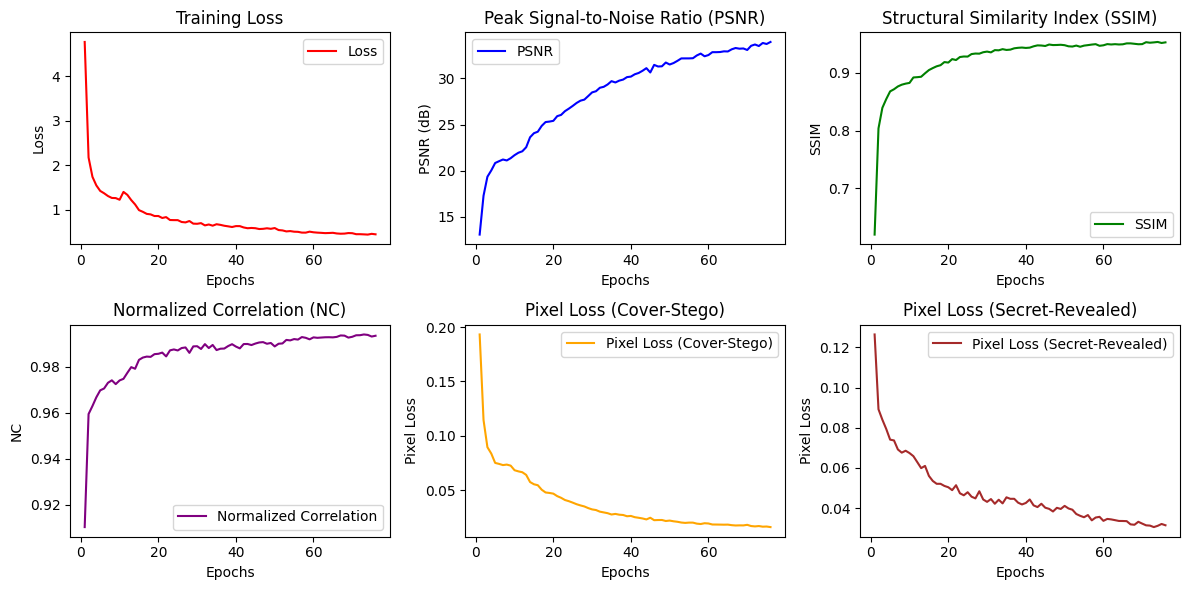


Final Evaluation Metrics:
Final Loss: 0.4495
Final PSNR: 33.9460 dB
Final SSIM: 0.9530
Final Normalized Correlation (NC): 0.9936
Final Pixel Loss (Cover-Stego): 0.0164
Final Pixel Loss (Secret-Revealed): 0.0315



In [15]:
plot_metrics(train_metrics)

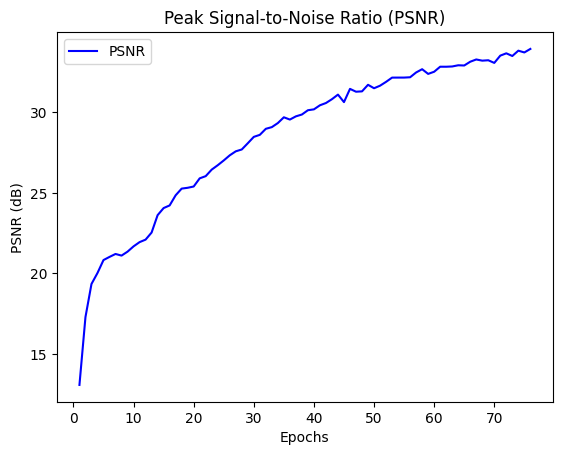

In [16]:
plot_psnr(train_metrics)

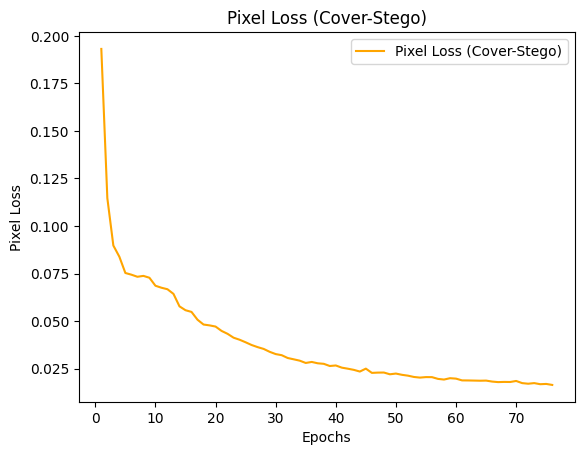

In [17]:
plot_cover_loss(train_metrics)

In [18]:
for epoch in range(0, len(train_metrics['loss'])):
    if (epoch + 1) % 15 == 0:  # Print every 10 epochs (1-based index)
        print(f"Epoch {epoch + 1}:")
        print(f"  Loss: {train_metrics['loss'][epoch]}")
        print(f"  PSNR: {train_metrics['psnr'][epoch]}")
        print(f"  SSIM: {train_metrics['ssim'][epoch]}")
        print(f"  NC: {train_metrics['nc'][epoch]}")
        print(f"  Pixel Loss Cover/Stego: {train_metrics['pixel_loss_cover_stego'][epoch]}")
        print(f"  Pixel Loss Secret Revealed: {train_metrics['pixel_loss_secret_revealed'][epoch]}")
        print("-" * 50)  # Print separator for clarity

Epoch 15:
  Loss: 0.9933509362071596
  PSNR: 24.05680222036951
  SSIM: 0.904849067408377
  NC: 0.9830797679761317
  Pixel Loss Cover/Stego: 0.05568376141088327
  Pixel Loss Secret Revealed: 0.05604585501028917
--------------------------------------------------
Epoch 30:
  Loss: 0.6864031859678436
  PSNR: 28.480885211085774
  SSIM: 0.9369401382526178
  NC: 0.9890078746211466
  Pixel Loss Cover/Stego: 0.032605883104638904
  Pixel Loss Secret Revealed: 0.04313669094806098
--------------------------------------------------
Epoch 45:
  Loss: 0.5868969533924033
  PSNR: 30.6404985557676
  SSIM: 0.9466699730039267
  NC: 0.9901576479067977
  Pixel Loss Cover/Stego: 0.024950675532241298
  Pixel Loss Secret Revealed: 0.04023879836679129
--------------------------------------------------
Epoch 60:
  Loss: 0.49488319837883193
  PSNR: 32.528352862253236
  SSIM: 0.9478587205497382
  NC: 0.9928546454269849
  Pixel Loss Cover/Stego: 0.019688826120161106
  Pixel Loss Secret Revealed: 0.03369646701298615

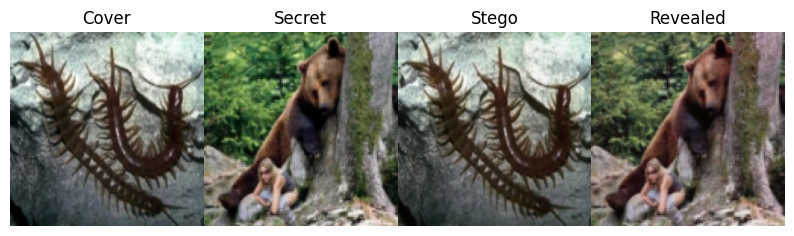

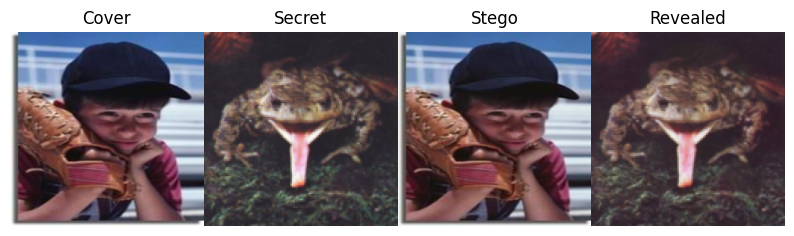

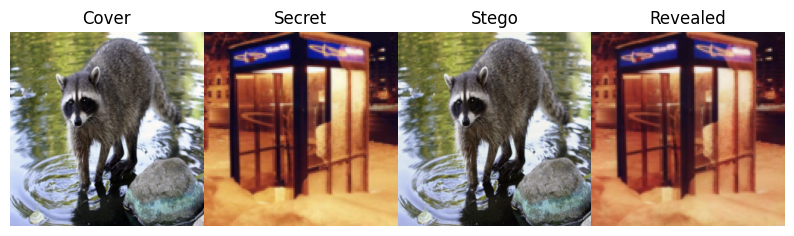

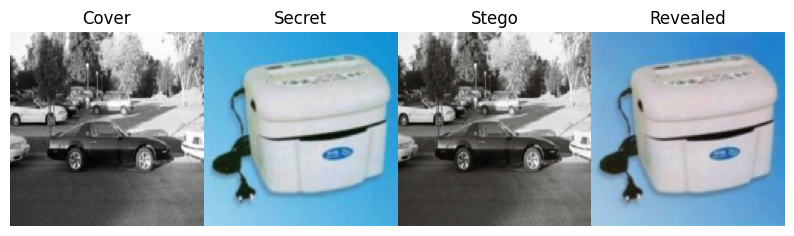

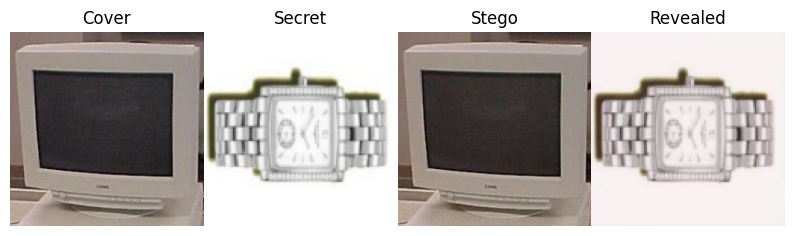

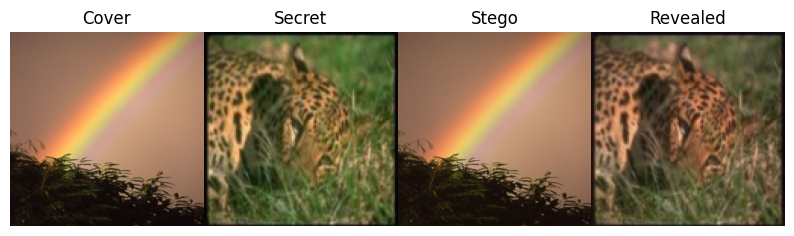

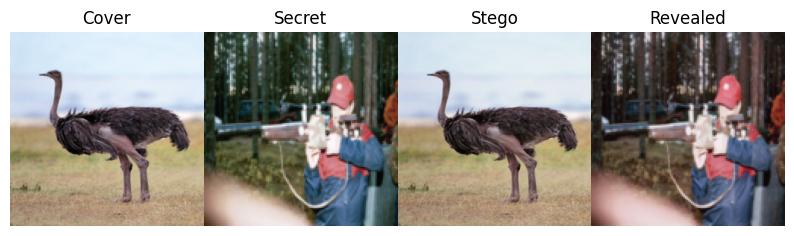

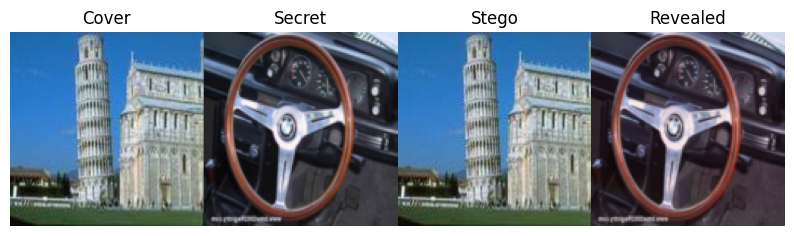

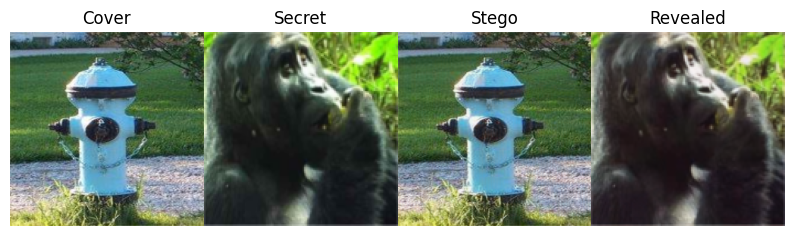


Test Results (Attacks: None): Loss: 0.4817, PSNR: 34.2000, SSIM: 0.9641, NC: 0.9930, Pixel Loss (Cover-Stego): 0.0158, Pixel Loss (Secret-Revealed): 0.0336



In [19]:
test_metrics = test(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               beta = 0.9,
               mse_cover_weight = 0.4,
               mse_secret_weight = 0.4,
               perceptual_cover_weight=0.7,
               perceptual_secret_weight=0.7,
               psnr_weight=10,
               ssim_weight=2,
               nc_weight=1,
               visualize = 1,
               attacks=None,                  
               device=device)

In [20]:
torch.save(prep_net.state_dict(), "/kaggle/working/prep_net.pth")
torch.save(hide_net.state_dict(), "/kaggle/working/hide_net.pth")
torch.save(reveal_net.state_dict(), "/kaggle/working/reveal_net.pth")

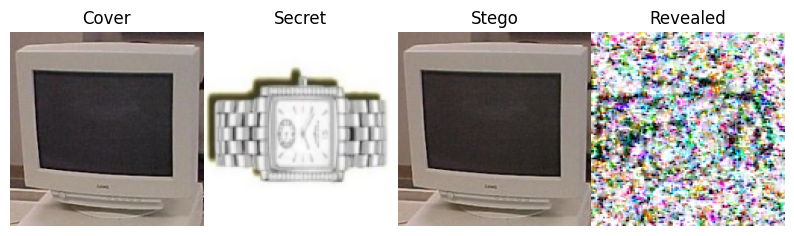


Test Results (Attacks: ['salt_and_pepper']): Loss: 6.0457, PSNR: 34.2000, SSIM: 0.9641, NC: 0.4948, Pixel Loss (Cover-Stego): 0.0158, Pixel Loss (Secret-Revealed): 0.2335



In [21]:
test_metrics = test(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               beta = 1,
               visualize = 5,
               attacks=['salt_and_pepper'],                  
               device=device)

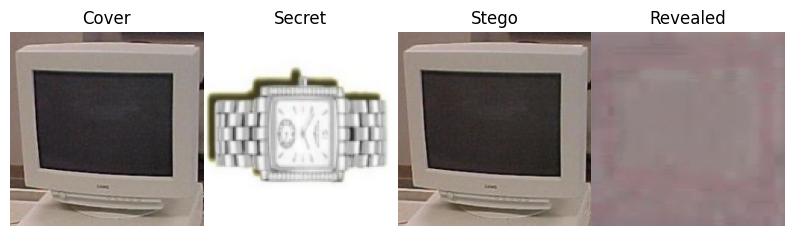


Test Results (Attacks: ['jpeg']): Loss: 3.0284, PSNR: 34.2000, SSIM: 0.9641, NC: 0.0476, Pixel Loss (Cover-Stego): 0.0158, Pixel Loss (Secret-Revealed): 0.2704



In [22]:
test_metrics = test(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               beta = 1,
               visualize = 5,
               attacks=['jpeg'],                  
               device=device)

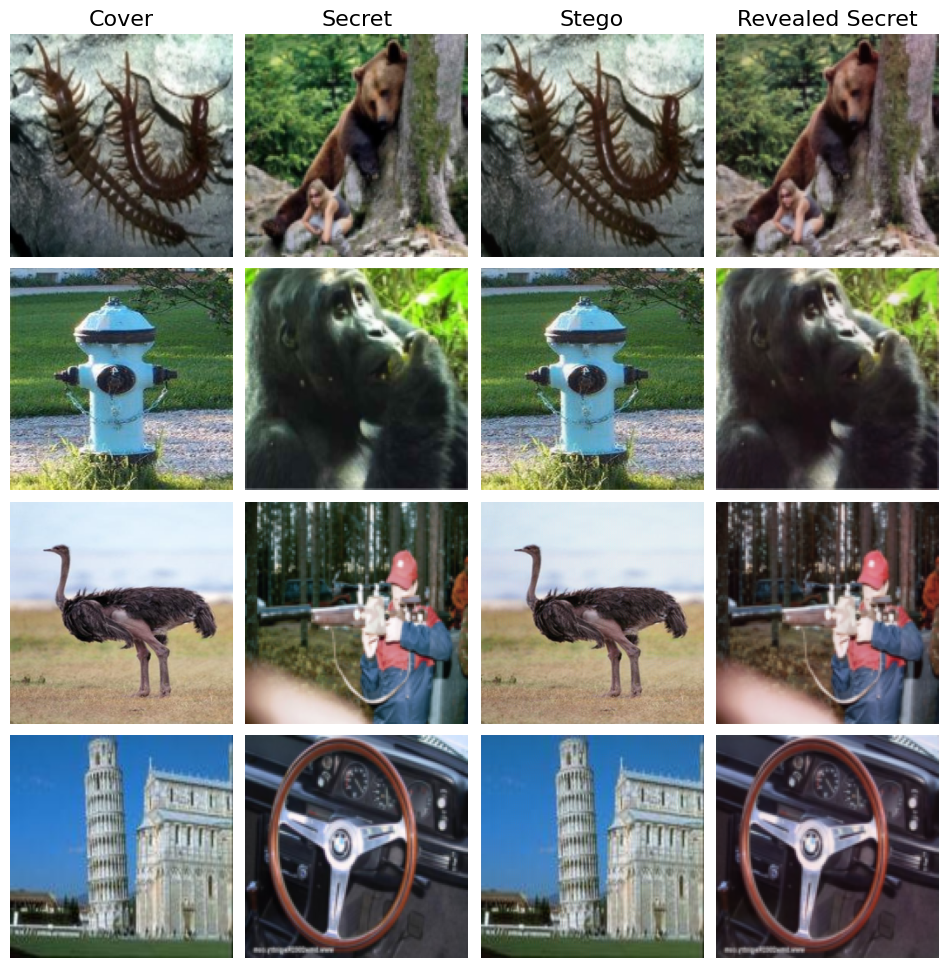

In [23]:
show_random_samples(prep_net, hide_net, reveal_net, test_loader, num_samples=4)

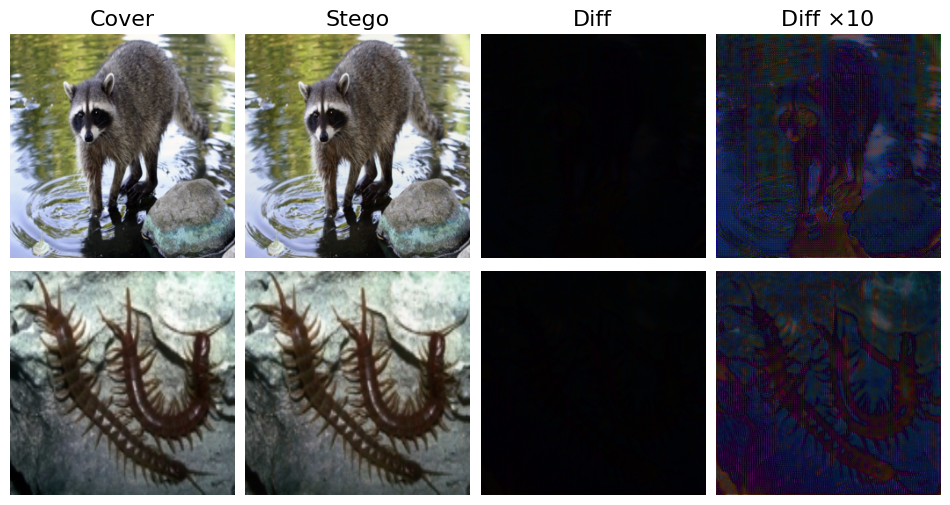

In [25]:
show_cover_stego_diffs(prep_net, hide_net, test_loader, num_samples=2)
